In [ ]:
!pip install -q albumentations opencv-python-headless scikit-learn seaborn

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!wget -q "https://github.com/MohamedAliHabib/Brain-Tumor-Detection/raw/master/brain_tumor_dataset.zip"
!unzip -q brain_tumor_dataset.zip
!ls brain_tumor_dataset/

unzip:  cannot find or open brain_tumor_dataset.zip, brain_tumor_dataset.zip.zip or brain_tumor_dataset.zip.ZIP.
ls: cannot access 'brain_tumor_dataset/': No such file or directory


In [ ]:
from google.colab import files
import zipfile

# 1. Go to: kaggle.com/datasets/ahmedhamada0/brain-tumor-detection
# 2. Click Download → saves brain-tumor-detection.zip to your PC
# 3. Run this cell and select the zip when the dialog opens:
uploaded = files.upload()

# 4. Extract it
with zipfile.ZipFile("brain-tumor-detection.zip", "r") as z:
    z.extractall("brain_tumor_dataset")

!ls brain_tumor_dataset/

In [ ]:
import zipfile, os

# The uploaded file is actually named archive.zip
with zipfile.ZipFile("archive (1).zip", "r") as z:
    z.extractall(".")

# Check what was extracted
os.listdir(".")

FileNotFoundError: [Errno 2] No such file or directory: 'archive (1).zip'

In [ ]:
import os

# Sometimes Kaggle zips have an extra nesting level — this handles both cases
if os.path.exists("brain_tumor_dataset/yes"):
    print("Structure is correct!")
elif os.path.exists("brain_tumor_dataset/brain_tumor_dataset/yes"):
    # Flatten the extra level
    import shutil
    shutil.move("brain_tumor_dataset/brain_tumor_dataset", "bdd_temp")
    shutil.rmtree("brain_tumor_dataset")
    shutil.move("bdd_temp", "brain_tumor_dataset")
    print("Fixed nested structure!")
else:
    # Show what's there so we can figure it out
    for root, dirs, files in os.walk("."):
        if "yes" in dirs or "no" in dirs:
            print(f"Found yes/no in: {root}")
            break
    print(os.listdir("."))

['.config', 'sample_data']


In [ ]:
yes = len(os.listdir("brain_tumor_dataset/yes"))
no  = len(os.listdir("brain_tumor_dataset/no"))
print(f"yes/ → {yes} images")
print(f"no/  → {no} images")

FileNotFoundError: [Errno 2] No such file or directory: 'brain_tumor_dataset/yes'

In [ ]:
import os

# See everything in the current directory
for root, dirs, files in os.walk("."):
    # Skip hidden folders and colab internals
    dirs[:] = [d for d in dirs if not d.startswith('.') and d != 'sample_data']
    level = root.replace(".", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show files 3 levels deep
        for f in files[:5]:  # first 5 files per folder
            print(f"{indent}  {f}")

./


In [ ]:
import os, cv2, random, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 60
LR         = 1e-4
SEED       = 42

CLASSES    = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = 4

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── PREPROCESSING ─────────────────────────────────────────
def preprocess_mri(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read: {img_path}")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
    img = cv2.resize(img, target_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# ── LOAD DATASET ──────────────────────────────────────────
def load_dataset():
    paths, labels = [], []
    for label, cls in enumerate(CLASSES):
        # Load from both Training and Testing folders
        for split in ['Training', 'Testing']:
            folder = os.path.join(split, cls)
            for ext in ['*.jpg','*.jpeg','*.png']:
                for fp in glob(os.path.join(folder, ext)):
                    paths.append(fp)
                    labels.append(label)
    return np.array(paths), np.array(labels)

paths, labels = load_dataset()
print(f"Total images: {len(paths)}")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {sum(labels==i)}")

# Combine everything and re-split properly
X_train_p, X_test_p, y_train, y_test = train_test_split(
    paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train_p, X_val_p, y_train, y_val = train_test_split(
    X_train_p, y_train, test_size=0.18, stratify=y_train, random_state=SEED)

print(f"\nSplit — Train: {len(X_train_p)} | Val: {len(X_val_p)} | Test: {len(X_test_p)}")

# ── AUGMENTATION ──────────────────────────────────────────
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.4),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
    A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(10,20),
                    hole_width_range=(10,20), p=0.2),
])

def load_images(paths_arr, augment=False):
    imgs = []
    for i, p in enumerate(paths_arr):
        img = preprocess_mri(p)
        if augment:
            img = train_aug(image=img)['image']
        imgs.append(img)
        if (i+1) % 100 == 0:
            print(f"  {i+1}/{len(paths_arr)} loaded...")
    return np.array(imgs, dtype='float32')

print("\nLoading training images...")
X_train = preprocess_input(load_images(X_train_p, augment=True))
print("Loading validation images...")
X_val   = preprocess_input(load_images(X_val_p,   augment=False))
print("Loading test images...")
X_test  = preprocess_input(load_images(X_test_p,  augment=False))
print("All images loaded!")

# One-hot encode labels
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

# ── CLASS WEIGHTS ─────────────────────────────────────────
cw_values = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw_values))
print(f"Class weights: {class_weights}")

# ── BUILD MODEL ───────────────────────────────────────────
def build_model():
    base = EfficientNetB3(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.6)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model  = models.Model(inputs, output)
    return model, base

model, base_model = build_model()
model.summary()

# ── CALLBACKS ─────────────────────────────────────────────
def get_callbacks(phase=1):
    return [
        callbacks.ModelCheckpoint(
            f'best_model_phase{phase}.keras',
            monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=12,
            restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ]

# ── PHASE 1: frozen base ───────────────────────────────────
model.compile(optimizer=optimizers.Adam(LR),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n=== Phase 1: Training head (base frozen) ===")
hist1 = model.fit(X_train, y_train_oh,
                  validation_data=(X_val, y_val_oh),
                  epochs=20, batch_size=BATCH_SIZE,
                  class_weight=class_weights,
                  callbacks=get_callbacks(1), verbose=1)

# ── PHASE 2: fine-tune top 20 layers ──────────────────────
print("\n=== Phase 2: Fine-tuning top 20 EfficientNetB3 layers ===")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(LR/10),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

hist2 = model.fit(X_train, y_train_oh,
                  validation_data=(X_val, y_val_oh),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=class_weights,
                  callbacks=get_callbacks(2), verbose=1)

# ── EVALUATION ────────────────────────────────────────────
print("\nEvaluating on test set...")
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')
auc = roc_auc_score(tf.keras.utils.to_categorical(y_test, NUM_CLASSES),
                    y_prob, multi_class='ovr', average='macro')

print(f"\n{'='*50}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  F1 Score      : {f1:.4f}")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# ── CONFUSION MATRIX ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — 4-class Brain Tumor')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
display(plt.gcf()); plt.close()

# ── TRAINING HISTORY ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_acc     = hist1.history['accuracy']     + hist2.history['accuracy']
all_val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
all_loss    = hist1.history['loss']         + hist2.history['loss']
all_val_loss= hist1.history['val_loss']     + hist2.history['val_loss']

axes[0].plot(all_acc, label='Train'); axes[0].plot(all_val_acc, label='Val')
axes[0].axvline(x=len(hist1.history['accuracy']), color='red', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(all_loss, label='Train'); axes[1].plot(all_val_loss, label='Val')
axes[1].axvline(x=len(hist1.history['loss']), color='red', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
display(plt.gcf()); plt.close()

print("\nDone! Outputs saved.")

Total images: 0
  glioma: 0
  meningioma: 0
  notumor: 0
  pituitary: 0


ValueError: With n_samples=0, test_size=0.15 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
import os, cv2, random, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32          # larger batch is fine now — images load one batch at a time
EPOCHS      = 60
LR          = 1e-4
SEED        = 42
CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = 4

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── PREPROCESSING ─────────────────────────────────────────
def preprocess_mri(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype='float32')
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray  = clahe.apply(gray)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype('float32')

# ── LOAD PATHS ONLY (no images in RAM) ───────────────────
def load_paths():
    paths, labels = [], []
    for label, cls in enumerate(CLASSES):
        for split in ['Training', 'Testing']:
            folder = os.path.join(split, cls)
            for ext in ['*.jpg','*.jpeg','*.png']:
                for fp in glob(os.path.join(folder, ext)):
                    paths.append(fp)
                    labels.append(label)
    return np.array(paths), np.array(labels)

paths, labels = load_paths()
print(f"Total images: {len(paths)}")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {sum(labels==i)}")

X_train_p, X_test_p, y_train, y_test = train_test_split(
    paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train_p, X_val_p, y_train, y_val = train_test_split(
    X_train_p, y_train, test_size=0.18, stratify=y_train, random_state=SEED)

print(f"Train: {len(X_train_p)} | Val: {len(X_val_p)} | Test: {len(X_test_p)}")

# ── AUGMENTATION ──────────────────────────────────────────
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
    A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(10,20),
                    hole_width_range=(10,20), p=0.2),
])

# ── DATA GENERATOR (loads one batch at a time) ────────────
class MRIGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size, augment=False, shuffle=True):
        self.paths      = paths
        self.labels     = labels
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, labs = [], []
        for i in batch_idx:
            img = preprocess_mri(self.paths[i])
            if self.augment:
                img = train_aug(image=img.astype('uint8'))['image'].astype('float32')
            imgs.append(preprocess_input(img))
            labs.append(self.labels[i])
        X = np.array(imgs, dtype='float32')
        y = tf.keras.utils.to_categorical(labs, NUM_CLASSES)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = MRIGenerator(X_train_p, y_train, BATCH_SIZE, augment=True)
val_gen   = MRIGenerator(X_val_p,   y_val,   BATCH_SIZE, augment=False, shuffle=False)
test_gen  = MRIGenerator(X_test_p,  y_test,  BATCH_SIZE, augment=False, shuffle=False)

print("Generators ready — no RAM preloading!")

# ── CLASS WEIGHTS ─────────────────────────────────────────
cw_values = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw_values))
print(f"Class weights: {class_weights}")

# ── BUILD MODEL ───────────────────────────────────────────
def build_model():
    base = EfficientNetB3(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.6)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, output), base

model, base_model = build_model()
model.summary()

# ── CALLBACKS ─────────────────────────────────────────────
def get_callbacks(phase):
    return [
        callbacks.ModelCheckpoint(
            f'best_model_phase{phase}.keras',
            monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=12,
            restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ]

# ── PHASE 1 ───────────────────────────────────────────────
model.compile(optimizer=optimizers.Adam(LR),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n=== Phase 1: Training head (base frozen) ===")
hist1 = model.fit(train_gen,
                  validation_data=val_gen,
                  epochs=20,
                  class_weight=class_weights,
                  callbacks=get_callbacks(1),
                  verbose=1)

# ── PHASE 2 ───────────────────────────────────────────────
print("\n=== Phase 2: Fine-tuning top 20 layers ===")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(LR/10),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

hist2 = model.fit(train_gen,
                  validation_data=val_gen,
                  epochs=EPOCHS,
                  class_weight=class_weights,
                  callbacks=get_callbacks(2),
                  verbose=1)

# ── EVALUATION ────────────────────────────────────────────
print("\nEvaluating on test set...")
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)
# test_gen doesn't shuffle so labels are in order
y_true = y_test[:len(y_pred)]

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted')
auc = roc_auc_score(tf.keras.utils.to_categorical(y_true, NUM_CLASSES),
                    y_prob, multi_class='ovr', average='macro')

print(f"\n{'='*50}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  F1 Score      : {f1:.4f}")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"{'='*50}")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# ── CONFUSION MATRIX ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150)
display(plt.gcf()); plt.close()

# ── TRAINING HISTORY ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
all_acc      = hist1.history['accuracy']     + hist2.history['accuracy']
all_val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
all_loss     = hist1.history['loss']         + hist2.history['loss']
all_val_loss = hist1.history['val_loss']     + hist2.history['val_loss']

axes[0].plot(all_acc, label='Train'); axes[0].plot(all_val_acc, label='Val')
axes[0].axvline(x=len(hist1.history['accuracy']), color='red',
                linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(all_loss, label='Train'); axes[1].plot(all_val_loss, label='Val')
axes[1].axvline(x=len(hist1.history['loss']), color='red',
                linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout(); plt.savefig('training_history.png', dpi=150)
display(plt.gcf()); plt.close()

print("\nDone!")

Total images: 0
  glioma: 0
  meningioma: 0
  notumor: 0
  pituitary: 0


ValueError: With n_samples=0, test_size=0.15 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/content/drive/MyDrive/BrainTumor', exist_ok=True)
shutil.copy('best_model_phase2.keras', '/content/drive/MyDrive/BrainTumor/best_model_phase2.keras')
print("Model saved to Drive!")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'best_model_phase2.keras'

NameError: name 'y_true' is not defined

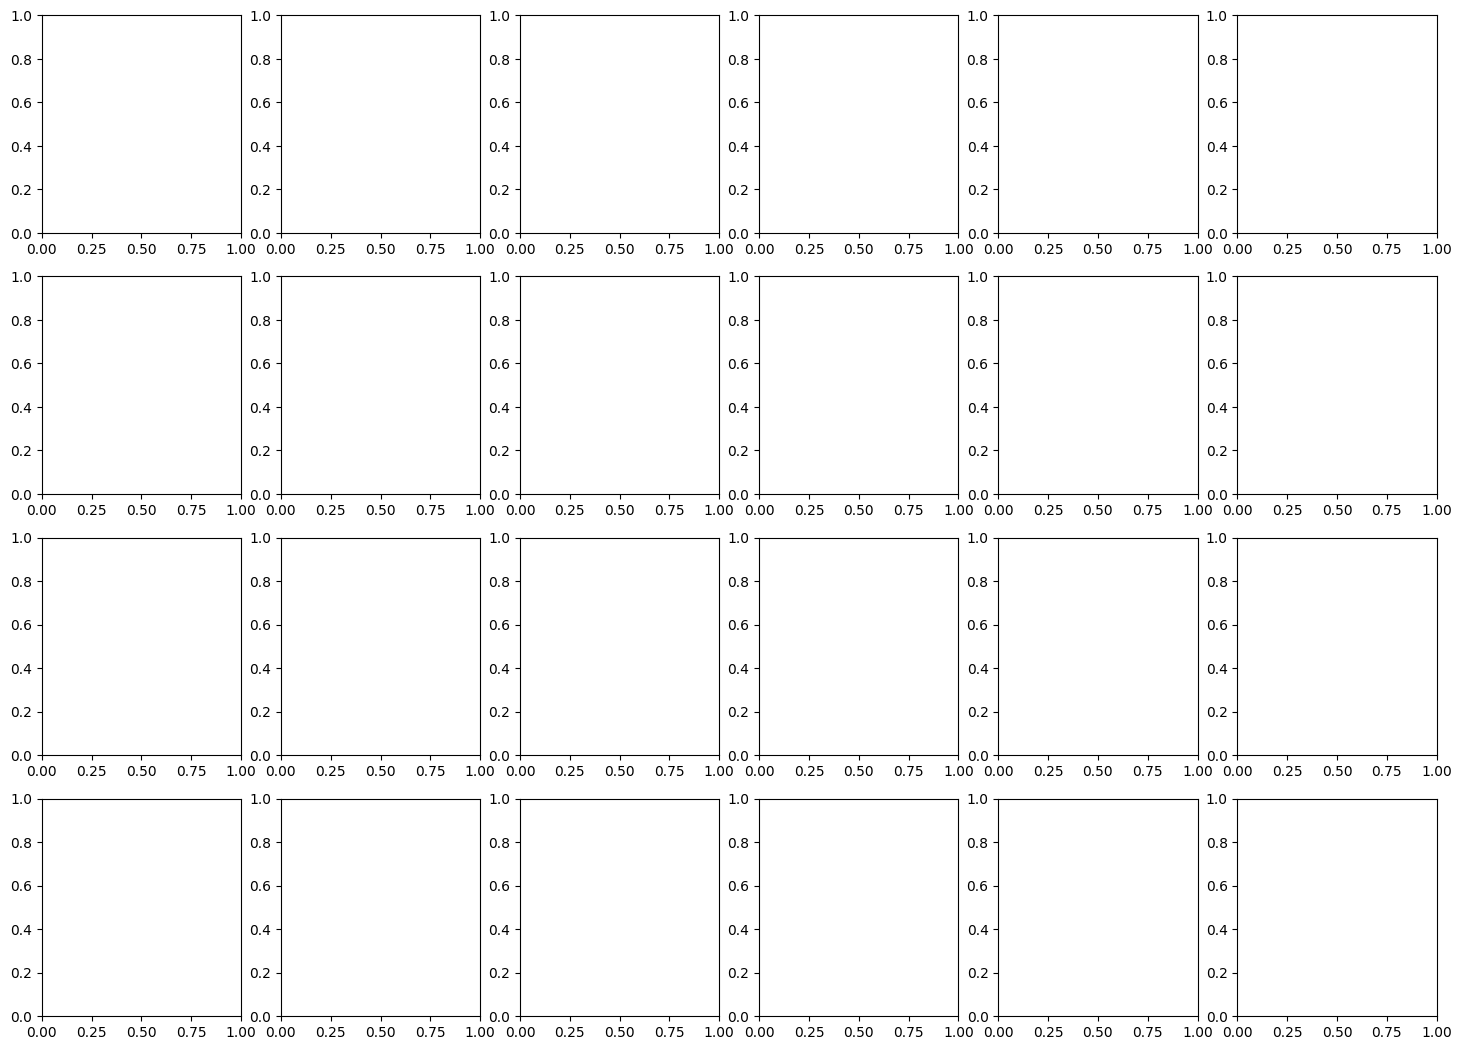

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

def make_gradcam(model, img_array):
    efficientnet_layer = model.get_layer('efficientnetb3')
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[efficientnet_layer.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(np.expand_dims(img_array, 0))
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]
    grads   = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = np.dot(conv_out[0], weights)
    cam     = np.maximum(cam, 0)
    cam     = cv2.resize(cam.numpy(), (224, 224))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_class)

def overlay_gradcam(original_img, cam):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (0.4 * heatmap + 0.6 * original_img).astype(np.uint8)

fig, axes = plt.subplots(4, 6, figsize=(18, 13))

for class_idx, class_name in enumerate(CLASSES):
    correct = [i for i in range(len(y_true))
               if y_true[i] == class_idx and y_pred[i] == class_idx][:2]
    for col, idx in enumerate(correct):
        raw_img  = preprocess_mri(X_test_p[idx])
        proc_img = preprocess_input(raw_img.copy().astype('float32'))
        cam, pred_cls = make_gradcam(model, proc_img)
        overlay  = overlay_gradcam(raw_img.astype(np.uint8), cam)
        bc = col * 3
        axes[class_idx][bc].imshow(raw_img.astype(np.uint8))
        axes[class_idx][bc].set_title(f'{class_name}\nOriginal', fontsize=8)
        axes[class_idx][bc].axis('off')
        axes[class_idx][bc+1].imshow(cam, cmap='jet')
        axes[class_idx][bc+1].set_title('Grad-CAM', fontsize=8)
        axes[class_idx][bc+1].axis('off')
        axes[class_idx][bc+2].imshow(overlay)
        axes[class_idx][bc+2].set_title(f'Pred: {CLASSES[pred_cls]}', fontsize=8)
        axes[class_idx][bc+2].axis('off')

plt.suptitle('Grad-CAM — Where the model looks for each tumor type', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150)
display(plt.gcf()); plt.close()
print("Grad-CAM done!")

NameError: name 'y_true' is not defined

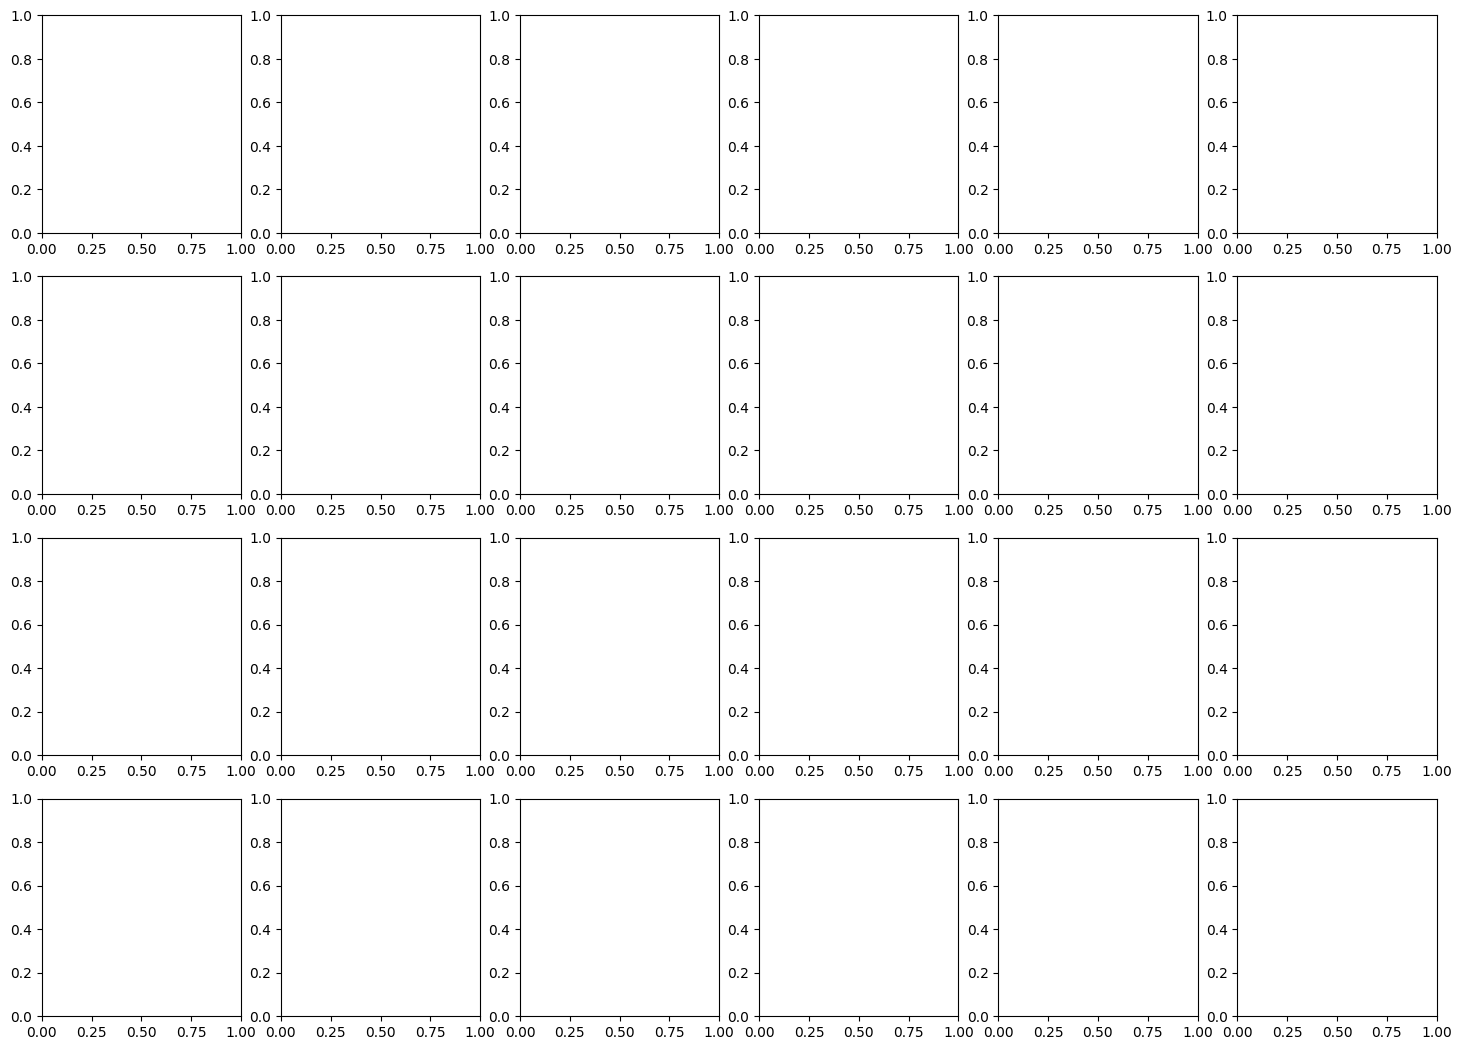

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

def make_gradcam(model, img_array):
    # Keras 3 fix: find the last conv layer inside EfficientNetB3 directly
    efficientnet = model.get_layer('efficientnetb3')

    # Get the last convolutional layer name inside the base model
    last_conv_layer = None
    for layer in efficientnet.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name
    print(f"Using layer: {last_conv_layer}") if last_conv_layer else None

    # Build grad model using the base model's own input/output
    conv_layer  = efficientnet.get_layer(last_conv_layer)
    inner_model = tf.keras.Model(
        inputs=efficientnet.input,
        outputs=[conv_layer.output, efficientnet.output]
    )

    # Full model without the base: just head layers
    inp = tf.keras.Input(shape=efficientnet.output.shape[1:])
    x   = inp
    head_started = False
    for layer in model.layers:
        if layer.name == 'efficientnetb3':
            head_started = True
            continue
        if head_started:
            x = layer(x)
    head_model = tf.keras.Model(inputs=inp, outputs=x)

    img_batch = np.expand_dims(img_array, 0)

    with tf.GradientTape() as tape:
        conv_out, base_out = inner_model(img_batch)
        tape.watch(conv_out)
        preds      = head_model(base_out)
        pred_class = tf.argmax(preds[0])
        loss       = preds[:, pred_class]

    grads   = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = np.dot(conv_out[0].numpy(), weights.numpy())
    cam     = np.maximum(cam, 0)
    cam     = cv2.resize(cam, (224, 224))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_class)

def overlay_gradcam(original_img, cam):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (0.4 * heatmap + 0.6 * original_img).astype(np.uint8)

# ── Generate Grad-CAM grid ────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(18, 13))

for class_idx, class_name in enumerate(CLASSES):
    correct = [i for i in range(len(y_true))
               if y_true[i] == class_idx and y_pred[i] == class_idx][:2]
    for col, idx in enumerate(correct):
        raw_img  = preprocess_mri(X_test_p[idx])
        proc_img = preprocess_input(raw_img.copy().astype('float32'))
        cam, pred_cls = make_gradcam(model, proc_img)
        overlay  = overlay_gradcam(raw_img.astype(np.uint8), cam)
        bc = col * 3
        axes[class_idx][bc].imshow(raw_img.astype(np.uint8))
        axes[class_idx][bc].set_title(f'{class_name}\nOriginal', fontsize=8)
        axes[class_idx][bc].axis('off')
        axes[class_idx][bc+1].imshow(cam, cmap='jet')
        axes[class_idx][bc+1].set_title('Grad-CAM', fontsize=8)
        axes[class_idx][bc+1].axis('off')
        axes[class_idx][bc+2].imshow(overlay)
        axes[class_idx][bc+2].set_title(f'Pred: {CLASSES[pred_cls]}', fontsize=8)
        axes[class_idx][bc+2].axis('off')

plt.suptitle('Grad-CAM — Where the model looks for each tumor type', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150)
display(plt.gcf()); plt.close()
print("Grad-CAM saved!")

In [ ]:
!pip install -q gradio

import gradio as gr
import numpy as np, cv2
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_INFO = {
    'glioma':     'Glioma — arises from glial cells. Most common primary brain tumor.',
    'meningioma': 'Meningioma — grows in the meninges (brain lining). Usually benign.',
    'notumor':    'No tumor detected in this MRI scan.',
    'pituitary':  'Pituitary tumor — forms in the pituitary gland at the brain base.',
}

def predict(image):
    if image is None:
        return "Please upload an MRI image.", {}
    img_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray  = clahe.apply(gray)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img_bgr = img_bgr[y:y+h, x:x+w]
    img_bgr = cv2.resize(img_bgr, (224, 224))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype('float32')
    inp     = preprocess_input(img_rgb)
    inp     = np.expand_dims(inp, 0)
    probs   = model.predict(inp, verbose=0)[0]
    pred    = CLASSES[np.argmax(probs)]
    conf    = float(np.max(probs))
    info    = f"**{pred.upper()}** ({conf*100:.1f}% confidence)\n\n{CLASS_INFO[pred]}"
    scores  = {cls: float(p) for cls, p in zip(CLASSES, probs)}
    return info, scores

with gr.Blocks(title="Brain Tumor Detection") as app:
    gr.Markdown("## Brain Tumor MRI Classifier\nUpload a brain MRI scan to detect: **Glioma · Meningioma · No Tumor · Pituitary**")
    with gr.Row():
        with gr.Column():
            img_input = gr.Image(label="Upload MRI", type="numpy")
            btn = gr.Button("Analyze", variant="primary")
        with gr.Column():
            result_text  = gr.Markdown(label="Result")
            result_chart = gr.Label(label="Confidence Scores", num_top_classes=4)
    btn.click(fn=predict, inputs=img_input, outputs=[result_text, result_chart])
    gr.Examples(examples=[[p] for p in X_test_p[:6]], inputs=img_input)

app.launch(share=True)

NameError: name 'X_test_p' is not defined

In [ ]:
import panel as pn
import param
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image
import io

pn.extension()

# Global config and classes
IMG_SIZE    = 224
CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = 4
CLASS_INFO = {
    'glioma':     'Glioma — arises from glial cells. Most common primary brain tumor.',
    'meningioma': 'Meningioma — grows in the meninges (brain lining). Usually benign.',
    'notumor':    'No tumor detected in this MRI scan.',
    'pituitary':  'Pituitary tumor — forms in the pituitary gland at the brain base.',
}

# Load the trained model
try:
    # Assuming the model was saved to Google Drive as instructed previously
    model = tf.keras.models.load_model('/content/drive/MyDrive/BrainTumor/best_model_phase2.keras')
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}. Make sure the model is in /content/drive/MyDrive/BrainTumor/best_model_phase2.keras")
    model = None # Handle case where model isn't loaded

# --- PREPROCESSING FUNCTION (adapted from j7RuRpiCpgue) ---
def preprocess_mri_for_panel(image_bytes):
    # Convert bytes to numpy array
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR) # Decode image from bytes

    if img is None:
        # Return a black image with the correct shape and type if decoding fails
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype='float32')

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray  = clahe.apply(gray)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype('float32') # Keep as float32 for consistency before preprocess_input

# --- GRAD-CAM FUNCTIONS (adapted from iU-yUb5H9yZ6) ---
def make_gradcam(model, img_array):
    if model is None:
        return np.zeros((IMG_SIZE, IMG_SIZE)), 0 # Return blank CAM and class 0

    efficientnet = model.get_layer('efficientnetb3')
    last_conv_layer = None
    for layer in efficientnet.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name

    if not last_conv_layer:
        print("Could not find a convolutional layer in EfficientNetB3.")
        return np.zeros((IMG_SIZE, IMG_SIZE)), 0

    conv_layer  = efficientnet.get_layer(last_conv_layer)
    inner_model = tf.keras.Model(
        inputs=efficientnet.input,
        outputs=[conv_layer.output, efficientnet.output]
    )

    # Reconstruct the head of the model (layers after EfficientNetB3)
    inp = tf.keras.Input(shape=efficientnet.output.shape[1:])
    x   = inp
    head_started = False
    for layer in model.layers:
        if layer.name == 'efficientnetb3':
            head_started = True
            continue
        if head_started:
            x = layer(x)
    head_model = tf.keras.Model(inputs=inp, outputs=x)

    img_batch = np.expand_dims(img_array, 0)

    with tf.GradientTape() as tape:
        conv_out, base_out = inner_model(img_batch)
        tape.watch(conv_out)
        preds      = head_model(base_out)
        pred_class = tf.argmax(preds[0])
        loss       = preds[:, pred_class]

    grads   = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = np.dot(conv_out[0].numpy(), weights.numpy())
    cam     = np.maximum(cam, 0)
    cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_class)

def overlay_gradcam(original_img_np, cam):
    # original_img_np here is the output of preprocess_mri_for_panel, which is 0-255 float32
    original_img_uint8 = original_img_np.astype(np.uint8)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    # Blend original image (0.6) with heatmap (0.4)
    overlay = cv2.addWeighted(original_img_uint8, 0.6, heatmap, 0.4, 0)
    return overlay


class BrainTumorClassifier(param.Parameterized):
    file_input = pn.widgets.FileInput(accept='.png, .jpg, .jpeg', width=300)
    prediction_output = pn.pane.Markdown("")
    gradcam_image = pn.pane.Matplotlib(sizing_mode='fixed', width=IMG_SIZE * 2, height=IMG_SIZE + 50) # Adjust height for titles

    def __init__(self, model_loaded, **params):
        super().__init__(**params)
        self.model = model_loaded
        self.prediction_output.object = "Upload an MRI image to classify." # Initial message
        # Initialize an empty matplotlib figure for the Grad-CAM pane
        self.gradcam_image.object = plt.figure(figsize=(2,1))
        plt.close(self.gradcam_image.object) # Close to prevent display of empty figure

    @param.depends('file_input.value', watch=True)
    def _update_output(self):
        if self.file_input.value is None:
            self.prediction_output.object = "Upload an MRI image to classify."
            # Clear the Grad-CAM display
            self.gradcam_image.object = plt.figure(figsize=(2,1))
            plt.close(self.gradcam_image.object)
            return

        image_bytes = self.file_input.value

        # Raw image for initial display (resized but not further processed)
        try:
            raw_image_for_display = np.array(Image.open(io.BytesIO(image_bytes)).resize((IMG_SIZE, IMG_SIZE)))
        except Exception as e:
            self.prediction_output.object = f"Error reading image: {e}"
            self.gradcam_image.object = plt.figure(figsize=(2,1))
            plt.close(self.gradcam_image.object)
            return

        # Preprocess image using the custom MRI preprocessing function
        preprocessed_img = preprocess_mri_for_panel(image_bytes)
        # Further preprocess for the EfficientNet model (normalization)
        processed_for_model = preprocess_input(preprocessed_img.copy())

        if self.model:
            # Prediction
            probs   = self.model.predict(np.expand_dims(processed_for_model, 0), verbose=0)[0]
            pred_idx = np.argmax(probs)
            pred_class = CLASSES[pred_idx]
            conf    = float(np.max(probs))

            info    = f"**Predicted Class: {pred_class.upper()}** ({conf*100:.1f}% confidence)\n\n{CLASS_INFO.get(pred_class, 'Unknown type.')}\n\n**Confidence Scores:**\n"
            for cls, p in zip(CLASSES, probs):
                info += f"- {cls.capitalize()}: {p*100:.1f}%\n"
            self.prediction_output.object = info

            # Grad-CAM
            cam, gradcam_pred_cls = make_gradcam(self.model, processed_for_model)
            # Use `preprocessed_img` (0-255) for overlay_gradcam as it's the brain-extracted version
            overlay_img = overlay_gradcam(preprocessed_img, cam)

            # Create a matplotlib figure to display original and Grad-CAM overlay
            fig, axes = plt.subplots(1, 2, figsize=(9, 4.5)) # Adjust figsize for better display
            axes[0].imshow(raw_image_for_display) # Show original uploaded image before any preprocessing for context
            axes[0].set_title('Original MRI Scan')
            axes[0].axis('off')

            axes[1].imshow(overlay_img)
            axes[1].set_title(f'Grad-CAM (Predicted: {CLASSES[pred_idx]})')
            axes[1].axis('off')

            plt.tight_layout()
            self.gradcam_image.object = fig # Update the Panel pane with the new figure
            plt.close(fig) # Close the figure to free memory after updating the pane
        else:
            self.prediction_output.object = "Model not loaded. Cannot make predictions."
            # Clear Grad-CAM display if model is not available
            self.gradcam_image.object = plt.figure(figsize=(2,1))
            plt.close(self.gradcam_image.object)

    def view(self):
        return pn.Column(
            pn.pane.Markdown("# Brain Tumor MRI Classifier Dashboard", width=800),
            pn.pane.Markdown("Upload an MRI image (`.png`, `.jpg`, or `.jpeg`) to get a classification and Grad-CAM visualization."),
            pn.Row(
                pn.Column(
                    self.file_input,
                    pn.Spacer(height=20),
                    self.prediction_output,
                ),
                pn.Column(
                    self.gradcam_image
                )
            )
        )

# Instantiate the app
if model is None:
    # If model loading failed, inform the user and skip app creation
    classifier_app_view = pn.pane.Markdown("Error: Model could not be loaded. Please ensure `best_model_phase2.keras` is in `/content/drive/MyDrive/BrainTumor/` and try again.")
else:
    classifier_app_instance = BrainTumorClassifier(model_loaded=model)
    classifier_app_view = classifier_app_instance.view()

# Display the Panel app
classifier_app_view.servable()
print("Panel dashboard created. Look for the output below or click the 'Open in new tab' button.")

Model loaded successfully!
Panel dashboard created. Look for the output below or click the 'Open in new tab' button.


In [ ]:
from google.colab import files

for f in ['confusion_matrix.png', 'training_history.png',
          'gradcam_results.png', 'best_model_phase2.keras']:
    files.download(f)
    print(f"Downloaded: {f}")

FileNotFoundError: Cannot find file: confusion_matrix.png